In [1]:
import pandas as pandas
import sqlite3
import os
import sys
import platform
import pandas as pd

In [2]:
#For each example in the blimp dataset, find the length and save 
#For examples with the two sentences having different lengths, decide what to do (easier is first to just save both the lengths separately, can always be combined later)

if "pop-os" in platform.node():
    ROOT = r"/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/"
else:
    ROOT = r'/gpfs/home4/athamma/repo/ss-llm/nanoGPT/'#Given a set of details, return a dataframe compiled with the details

RESULTS_ROOT = os.path.join(ROOT, "results")
SQL_DB = os.path.join(RESULTS_ROOT, "results.db")


def create_connection_cursor(db_file):
    """
    Create a database connection to the SQLite database specified by the db_file

    Args:
        db_file (str): database file

    Returns:
        Connection object or None
    """
    conn = sqlite3.connect(db_file)
    c = conn.cursor()
    return conn, c

conn, c = create_connection_cursor(SQL_DB)


#Other Utils
import io
import sys
import contextlib

@contextlib.contextmanager
def silence_prints():
    sys.stdout, old = io.StringIO(), sys.stdout
    try:
        yield
    finally:
        sys.stdout = old


In [3]:
#TODO - Currently I have data in the DB for individual blimp subtask data points, along with the length of the sentences for each of the two sentences in the data points
# 2 easy datapoints to create 
# Blimp subtask accuracy for each model, along with average length for that subtask
# Blimp Subtask accuracy for each model, along with average length when predictions are correct and when predictions are incorrect

### Notes from BLiMP Paper
 - 

Questions - 

In [4]:
#One approach is thaT - we can subset blimp data into training examples of a certain length and then calculate the accuracy for each model on that subset, for each subtask. 

In [ ]:
# MODEL_LIST_QUERY = '''
# SELECT DISTINCT ModelSurprisalScores.ModelID, Model.OutputFolderName, Model.BatchSize, Model.Dataset, Model.Seed, Model.MaskType FROM ModelSurprisalScores
# JOIN Model on Model.ModelID = ModelSurprisalScores.ModelID
# WHERE Model.NumLayers = 6 
# AND ((Model.EchoicMemory=10 AND Model.MaskType="exponential_new" AND Model.MaskDecayRate=2) OR (Model.MaskType="Non" AND Model.CurriculumLearning=False)) 
# AND Model.Dataset in ("babylm_full_bpe_8k", "babylm_full_bpe_100M_8k")  
# AND Model.ModelID not in (5496427, 8456913)
# ORDER BY Seed, BatchSize, Dataset, MaskType
# '''


# model_id_list = pd.read_sql_query(MODEL_LIST_QUERY, conn)['ModelID'].unique().tolist()

# #model_id_list = model_id_list[:1]

# print(len(model_id_list), model_id_list)

62 [8465733, 8465085, 6892214, 6839425, 8117279, 8117319, 8465604, 8465082, 6892212, 6839403, 8111923, 8111939, 8465611, 8465091, 6892220, 6839430, 8111928, 8111942, 8465607, 8465086, 6892216, 6839426, 8111925, 8111941, 8465610, 8465090, 6892219, 6839429, 8117282, 8117325, 8096895, 8465077, 6892222, 6681944, 8098216, 8111938, 8464992, 8456915, 8465605, 8465084, 6892213, 6839424, 8111924, 8111940, 8465609, 8465089, 6892218, 6839428, 8117281, 8117322, 8465612, 8465093, 6892221, 6839431, 8117283, 8117326, 8465608, 8465087, 6892217, 6839427, 8117280, 8117321]


In [17]:
data_dump_path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/final_paper_stuff/rundata.xlsx'
run_details_sheet = "Run Details"


run_data_unfiltered = pd.read_excel(data_dump_path, sheet_name=run_details_sheet) 


model_details_data = run_data_unfiltered[(run_data_unfiltered["curriculum_learning"]==False) &
                                (run_data_unfiltered["batch_size"]==32) &
                                (run_data_unfiltered["num_iterations"]==44000) &
                                (run_data_unfiltered["n_layer"]==6) &
                                (run_data_unfiltered["dataset"].isin(["babylm_full_bpe_8k", "babylm_full_bpe_100M_8k"])) &
                                
                                (
                                    (
                                        (run_data_unfiltered["echoic_memory"].isin([10]) & (run_data_unfiltered["mask_decay_rate"].isin([2]))) & (run_data_unfiltered["mask_type"].isin(["exponential_new"]))
                                    ) |
                                        (run_data_unfiltered["mask_type"].isin(["Non"]))
                                )
                            
                                ][["run_id", "output_folder_name", "mask_type", "mask_decay_rate", "echoic_memory", "seed", "dataset"]].assign(mask_type=lambda x: pd.Categorical(x["mask_type"], categories=["Non", "exponential_new"], ordered=True)).sort_values(by=["mask_type", "mask_decay_rate"])
                                        
model_details_data = model_details_data[~model_details_data["run_id"].isin([5734459, 5496427, 6617787, 8465077])]

#print(model_details_data.groupby(["dataset", "mask_type", "mask_decay_rate", "echoic_memory"]).size())

#model_details_data
model_details_data["condition"] = (model_details_data["mask_type"].astype(str).replace({"Non": "nomask", "exponential_new": "ee"}) + model_details_data["mask_decay_rate"].astype(int).astype(str).str.zfill(3).replace("000","") + "_EM" + model_details_data["echoic_memory"].astype(str).str.zfill(2))

condition_triplet_map = {"nomask_EM01": "Perfect\nMemory",
                        "ee002_EM10": "Fleeting\nMemory"}

model_details_data["condition"] = pd.Categorical(model_details_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
model_details_data = model_details_data.sort_values(by=["dataset", "condition", "seed"])

model_details_data["condition"] = model_details_data["condition"].map(condition_triplet_map)

model_details_data["dataset"] = model_details_data["dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})

model_id_list = model_details_data["run_id"].unique().tolist()

model_details_data

,run_id,output_folder_name,mask_type,mask_decay_rate,echoic_memory,seed,dataset,condition
250,8465733,out-babylm_full_bpe_100M_8k-6x6-nomask-8465733_s9,Non,0.0,1,9,100M,Perfect\nMemory
255,8465604,out-babylm_full_bpe_100M_8k-6x6-nomask-8465604...,Non,0.0,1,42,100M,Perfect\nMemory
248,8465611,out-babylm_full_bpe_100M_8k-6x6-nomask-8465611...,Non,0.0,1,466,100M,Perfect\nMemory
252,8465607,out-babylm_full_bpe_100M_8k-6x6-nomask-8465607...,Non,0.0,1,616,100M,Perfect\nMemory
247,8465610,out-babylm_full_bpe_100M_8k-6x6-nomask-8465610...,Non,0.0,1,869,100M,Perfect\nMemory
193,8096895,out-babylm_full_bpe_100M_8k-6x6-nomask-8096895,Non,0.0,1,1337,100M,Perfect\nMemory
251,8465605,out-babylm_full_bpe_100M_8k-6x6-nomask-8465605...,Non,0.0,1,2347,100M,Perfect\nMemory
254,8465609,out-babylm_full_bpe_100M_8k-6x6-nomask-8465609...,Non,0.0,1,6747,100M,Perfect\nMemory
249,8465612,out-babylm_full_bpe_100M_8k-6x6-nomask-8465612...,Non,0.0,1,11111,100M,Perfect\nMemory
253,8465608,out-babylm_full_bpe_100M_8k-6x6-nomask-8465608...,Non,0.0,1,46674,100M,Perfect\nMemory


In [18]:
MODEL_DATA_QUERY = '''
SELECT BlimpResultsSubtaskwiseBreakdown.ModelID as ModelID, BlimpResultsSubtaskwiseBreakdown.PredictedClass as PredictedClass,
BlimpSubtaskGroundTruth.SentenceGoodWordLength as SentenceGoodWordLength, BlimpSubtaskGroundTruth.SentenceBadWordLength as SentenceBadWordLength, BlimpSubtaskGroundTruth.RowIdx as RowIdx, BlimpSubtaskGroundTruth.Subtask as Subtask, BlimpSubtaskGroundTruth.TaskType as TaskType

FROM BlimpResultsSubtaskwiseBreakdown
JOIN BlimpSubtaskGroundTruth on BlimpResultsSubtaskwiseBreakdown.RowIdx = BlimpSubtaskGroundTruth.RowIdx
WHERE BlimpResultsSubtaskwiseBreakdown.ModelID in ({})
'''

model_data_df = pd.read_sql_query(MODEL_DATA_QUERY.format(",".join([str(x) for x in model_id_list])), conn)
model_data_df

,ModelID,PredictedClass,SentenceGoodWordLength,SentenceBadWordLength,RowIdx,Subtask,TaskType
0,6681944,Good,4,4,1,anaphor_agreement,blimp
1,6681944,Good,5,5,2,anaphor_agreement,blimp
2,6681944,Good,5,5,3,anaphor_agreement,blimp
3,6681944,Good,4,4,4,anaphor_agreement,blimp
4,6681944,Good,3,3,5,anaphor_agreement,blimp
...,...,...,...,...,...,...,...
2531195,8465733,Good,3,3,39129,irregular_forms,blimp
2531196,8465733,Good,5,5,39130,irregular_forms,blimp
2531197,8465733,Good,5,5,39131,irregular_forms,blimp
2531198,8465733,Good,5,5,39132,irregular_forms,blimp


In [26]:
#sample lineplot of accuracy vs length for one model

model_data_df["SentenceLength"] = (model_data_df["SentenceGoodWordLength"] + model_data_df["SentenceBadWordLength"])/2
model_data_df["SentenceLength"] = model_data_df["SentenceLength"].astype(int)
model_data_df["SentenceLength"] = model_data_df["SentenceLength"].apply(lambda x: x if x < 20 else 20)

model_line_accuracy = model_data_df[model_data_df['TaskType'] == 'blimp'].groupby(['ModelID', 'SentenceLength', 'PredictedClass']).size().unstack().fillna(0)
model_line_accuracy['Total'] = model_line_accuracy.sum(axis=1)
model_line_accuracy["Accuracy"] = model_line_accuracy["Good"] / model_line_accuracy["Total"]
model_line_accuracy = model_line_accuracy.reset_index()

model_line_accuracy = model_line_accuracy.merge(model_details_data[["run_id", "condition", "dataset"]], left_on="ModelID", right_on="run_id")

model_line_accuracy


,ModelID,SentenceLength,Bad,Good,Total,Accuracy,run_id,condition,dataset
0,6681944,2,145,333,478,0.696653,6681944,Fleeting\nMemory,10M
1,6681944,3,913,2082,2995,0.695159,6681944,Fleeting\nMemory,10M
2,6681944,4,1609,4264,5873,0.726034,6681944,Fleeting\nMemory,10M
3,6681944,5,2220,6726,8946,0.751844,6681944,Fleeting\nMemory,10M
4,6681944,6,2414,6225,8639,0.720570,6681944,Fleeting\nMemory,10M
...,...,...,...,...,...,...,...,...,...
755,8465733,16,173,313,486,0.644033,8465733,Perfect\nMemory,100M
756,8465733,17,82,148,230,0.643478,8465733,Perfect\nMemory,100M
757,8465733,18,55,84,139,0.604317,8465733,Perfect\nMemory,100M
758,8465733,19,16,45,61,0.737705,8465733,Perfect\nMemory,100M


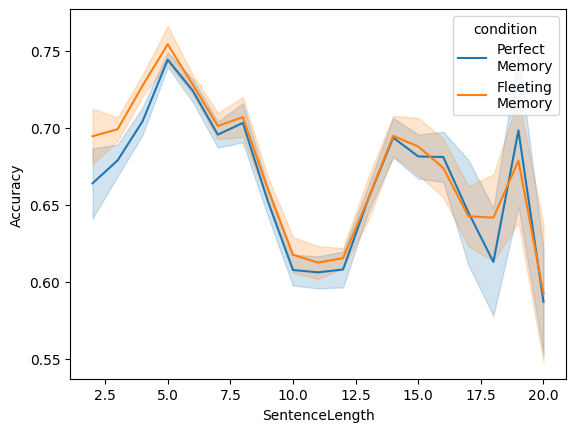

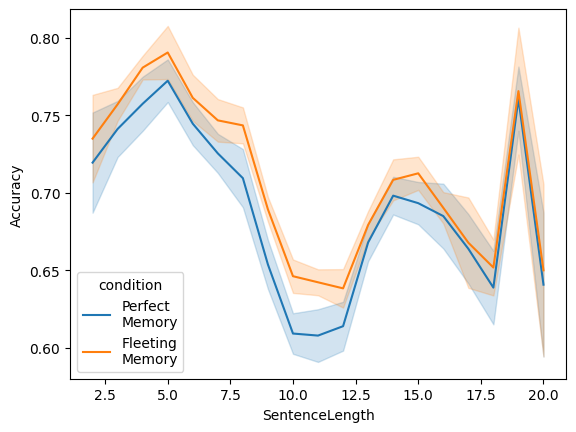

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data=model_line_accuracy[model_line_accuracy["dataset"]=="10M"], x="SentenceLength", y="Accuracy", hue="condition", errorbar="sd")
plt.show()

sns.lineplot(data=model_line_accuracy[model_line_accuracy["dataset"]=="100M"], x="SentenceLength", y="Accuracy", hue="condition", errorbar="sd")
plt.show()


In [54]:
model_subtask_line_accuracy = model_data_df[model_data_df['TaskType'] == 'blimp'].groupby(['ModelID', 'Subtask', 'SentenceLength', 'PredictedClass']).size().unstack().fillna(0)
model_subtask_line_accuracy['Total'] = model_subtask_line_accuracy.sum(axis=1)
model_subtask_line_accuracy["Accuracy"] = model_subtask_line_accuracy["Good"] / model_subtask_line_accuracy["Total"]
model_subtask_line_accuracy = model_subtask_line_accuracy.reset_index()

model_subtask_line_accuracy = model_subtask_line_accuracy.merge(model_details_data[["run_id", "condition", "dataset"]], left_on="ModelID", right_on="run_id")

#Drop Rows that have less than 10 examples
model_subtask_line_accuracy = model_subtask_line_accuracy[model_subtask_line_accuracy["Total"] > 10]

model_subtask_line_accuracy

,ModelID,Subtask,SentenceLength,Bad,Good,Total,Accuracy,run_id,condition,dataset
0,6681944,anaphor_agreement,3,83.0,288.0,371.0,0.776280,6681944,Fleeting\nMemory,10M
1,6681944,anaphor_agreement,4,219.0,840.0,1059.0,0.793201,6681944,Fleeting\nMemory,10M
2,6681944,anaphor_agreement,5,49.0,378.0,427.0,0.885246,6681944,Fleeting\nMemory,10M
3,6681944,anaphor_agreement,6,9.0,59.0,68.0,0.867647,6681944,Fleeting\nMemory,10M
4,6681944,anaphor_agreement,7,0.0,23.0,23.0,1.000000,6681944,Fleeting\nMemory,10M
...,...,...,...,...,...,...,...,...,...,...
6032,8465733,subject_verb_agreement,11,90.0,64.0,154.0,0.415584,8465733,Perfect\nMemory,100M
6033,8465733,subject_verb_agreement,12,71.0,42.0,113.0,0.371681,8465733,Perfect\nMemory,100M
6034,8465733,subject_verb_agreement,13,37.0,22.0,59.0,0.372881,8465733,Perfect\nMemory,100M
6035,8465733,subject_verb_agreement,14,24.0,10.0,34.0,0.294118,8465733,Perfect\nMemory,100M


Text(0.5, 0.98, 'Accuracy vs Sentence Length 10M Dataset')

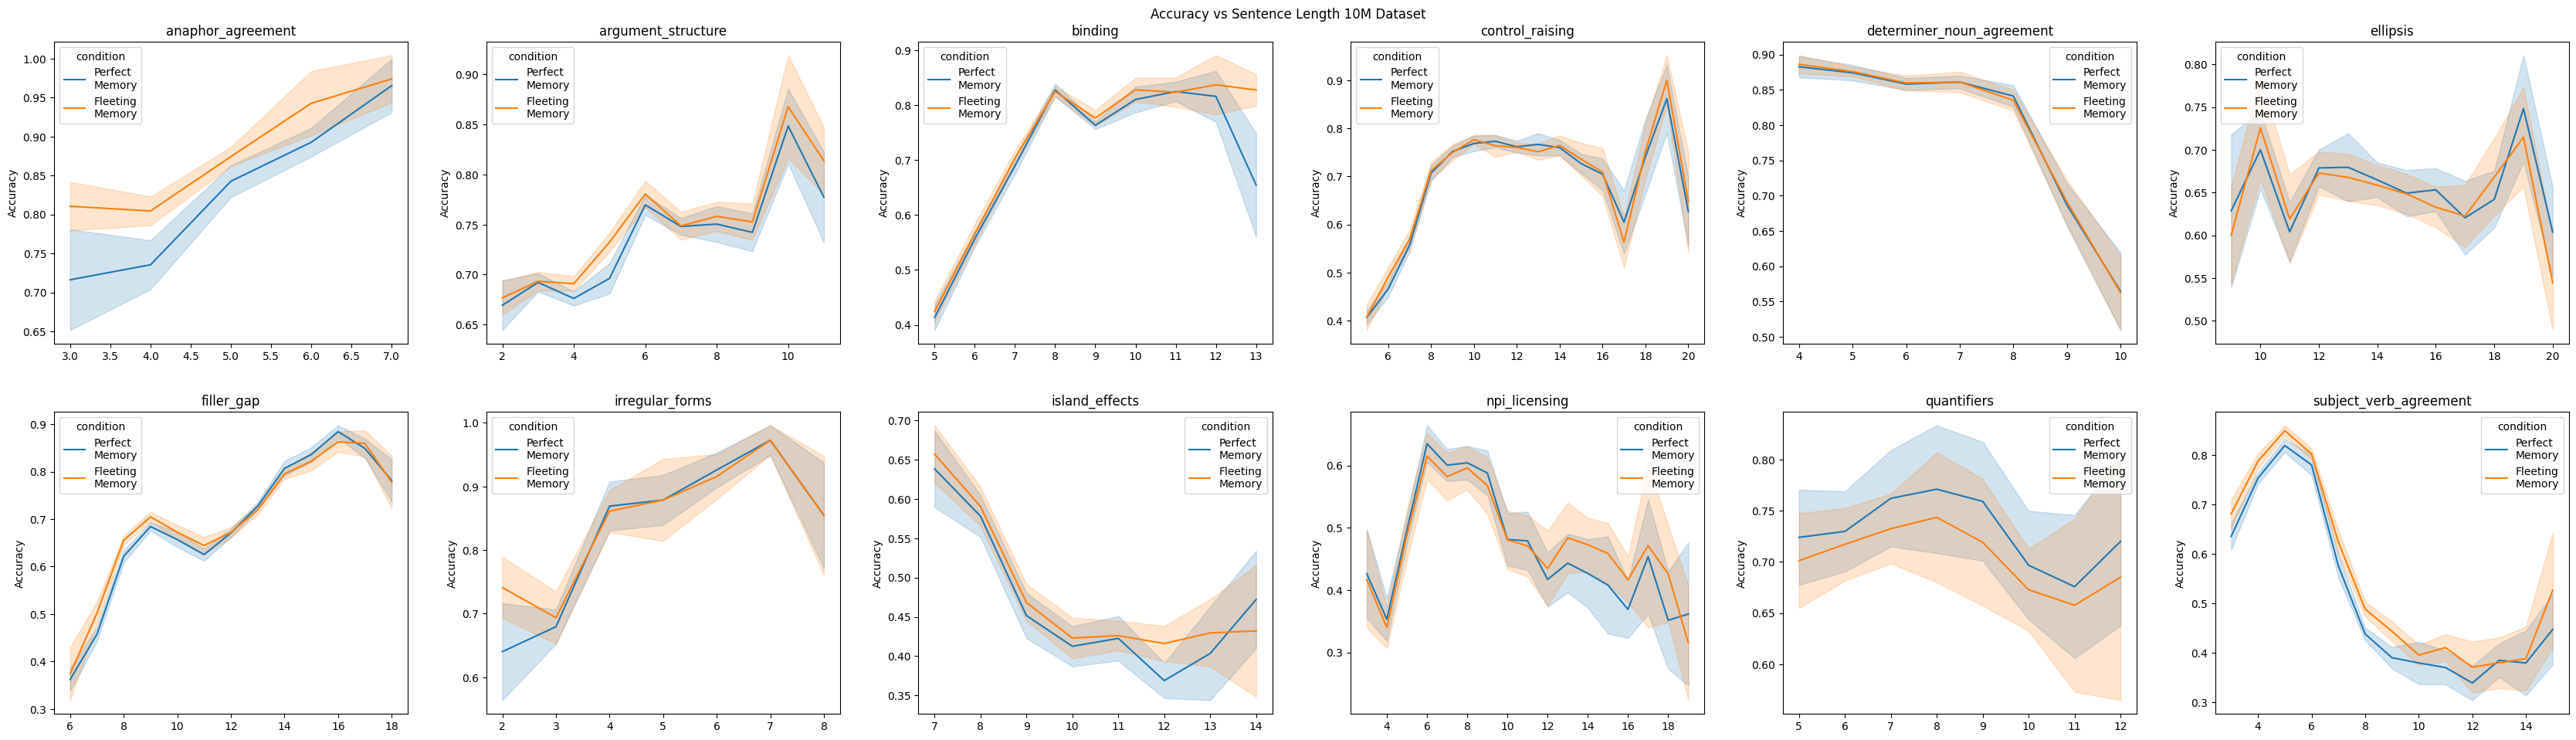

In [89]:
fig, ax = plt.subplots(2, 6, figsize=(34,10))

for i, subtask in enumerate(model_subtask_line_accuracy["Subtask"].unique()):
    sns.lineplot(data=model_subtask_line_accuracy[(model_subtask_line_accuracy["Subtask"]==subtask) & (model_subtask_line_accuracy["dataset"]=="10M")], x="SentenceLength", y="Accuracy", hue="condition", ax=ax[i//6, i%6], errorbar="sd")
    
    ax[i//6, i%6].set_title(subtask)
    ax[i//6, i%6].set_xlabel("")

#Increase the space between the plots
fig.tight_layout(pad=3.0)

fig.suptitle("Accuracy vs Sentence Length 10M Dataset")

Text(0.5, 0.98, 'Accuracy vs Sentence Length 100M Dataset')

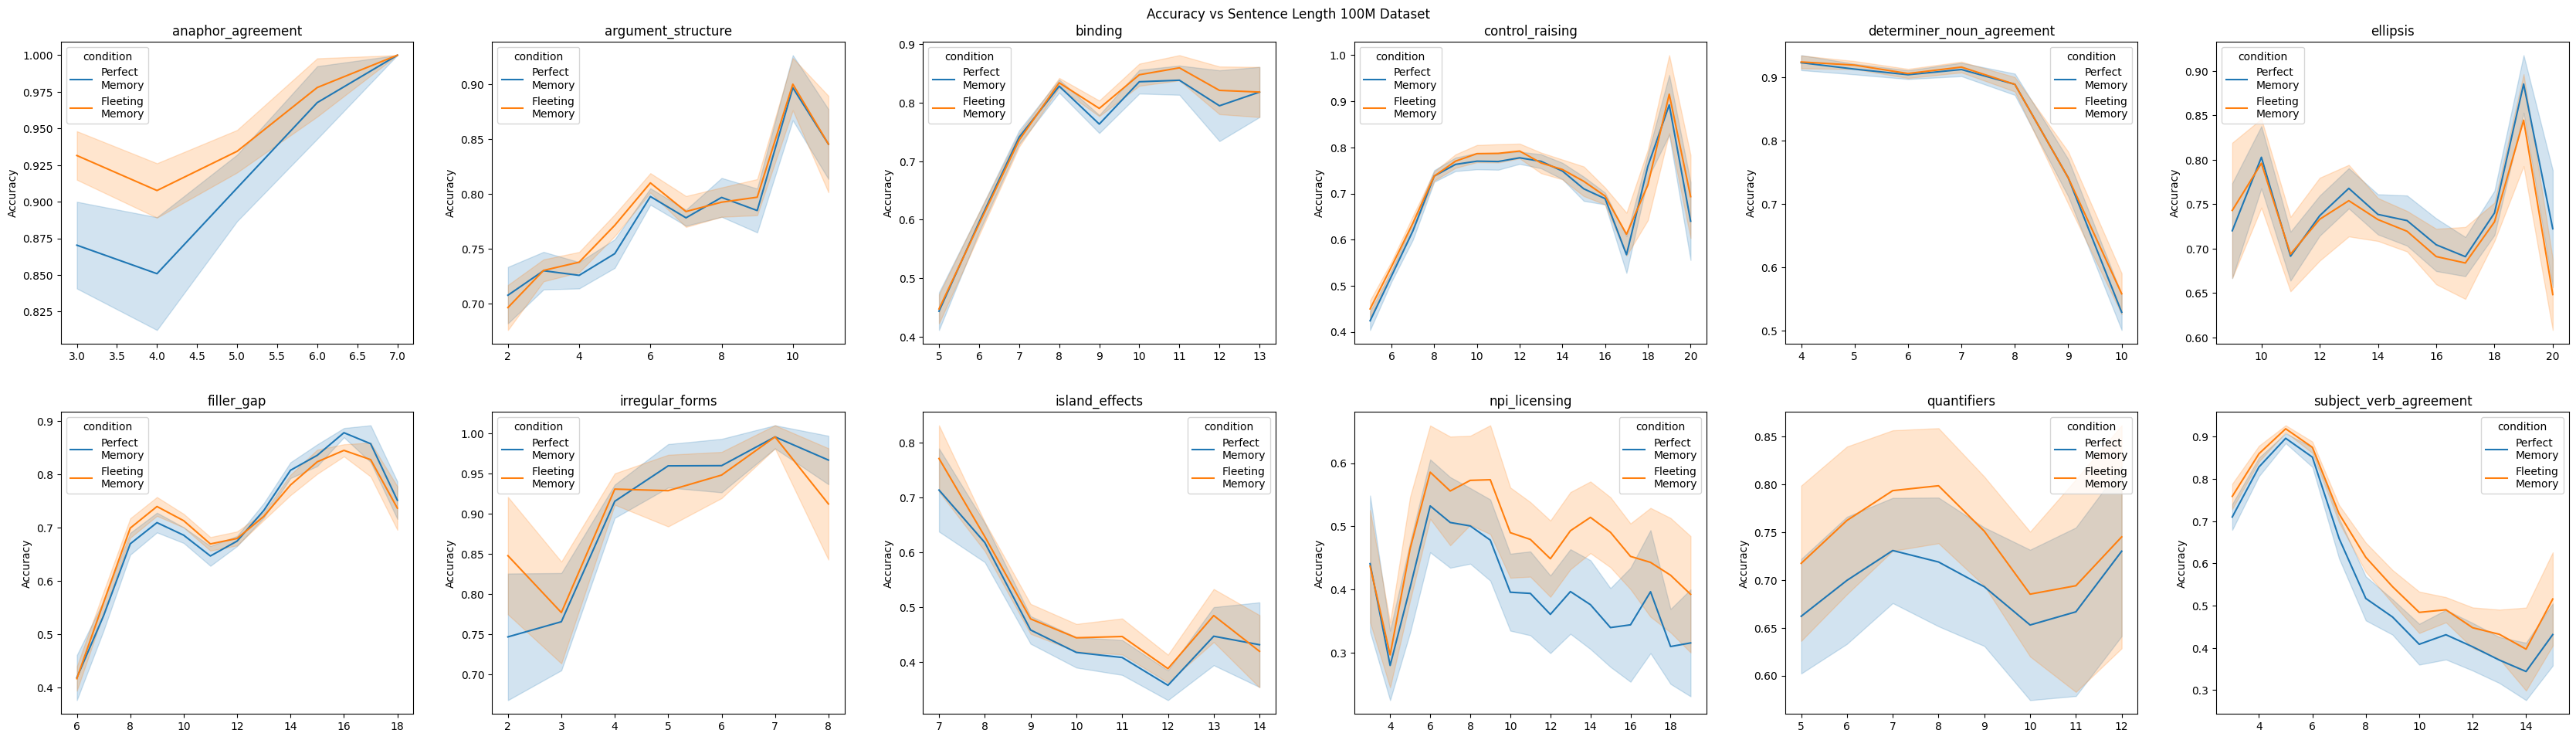

In [90]:
fig, ax = plt.subplots(2, 6, figsize=(34,10))

for i, subtask in enumerate(model_subtask_line_accuracy["Subtask"].unique()):
    sns.lineplot(data=model_subtask_line_accuracy[(model_subtask_line_accuracy["Subtask"]==subtask) & (model_subtask_line_accuracy["dataset"]=="100M")], x="SentenceLength", y="Accuracy", hue="condition", ax=ax[i//6, i%6], errorbar="sd")
    ax[i//6, i%6].set_title(subtask)
    ax[i//6, i%6].set_xlabel("")

#Increase the space between the plots
fig.tight_layout(pad=3.0)

fig.suptitle("Accuracy vs Sentence Length 100M Dataset")

In [ ]:
from tqdm import tqdm
tqdm.pandas()


def calculate_correlation(subgroup):
    #Correlation between sentence length correct (Good/Bad)
    subgroup["correct"] = (subgroup["PredictedClass"] == "Good").astype(int)

    #Correlation between sentence length and correct
    length_correct_correlation = subgroup[["correct", "SentenceLength"]].corr().iloc[0,1]

    return pd.Series({"length_correct_correlation": length_correct_correlation})

def calculate_binned_delta(subgroup):
    #Calculate Binned Difference in accuracy Where you bin long sentnences as sentences larger than median length
    subgroup["correct"] = (subgroup["PredictedClass"] == "Good").astype(int)

    median_length = subgroup["SentenceLength"].median()
    subgroup["binned_length"] = subgroup["SentenceLength"] > median_length
    
    binned_delta = subgroup.groupby(["binned_length"])["correct"].mean().diff().iloc[-1]

    return pd.Series({"binned_delta": binned_delta})

def calculate_logistic_regression(subgroup):
    #Calculate Logistic Regression Coefficients
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score

    subgroup["correct"] = (subgroup["PredictedClass"] == "Good").astype(int)
    X = subgroup["SentenceLength"].values.reshape(-1,1)
    y = subgroup["correct"]

    lr = LogisticRegression()
    lr.fit(X, y)

    return pd.Series({"logistic_regression_coeff": lr.coef_[0][0]})

model_correlation_results = model_data_df[model_data_df['TaskType'] == 'blimp'].groupby(["ModelID", "Subtask"]).progress_apply(calculate_correlation)

model_correlation_results["binned_delta"] = model_data_df[model_data_df['TaskType'] == 'blimp'].groupby(["ModelID", "Subtask"]).progress_apply(calculate_binned_delta)
model_correlation_results["logistic_regression_coeff"] = model_data_df[model_data_df['TaskType'] == 'blimp'].groupby(["ModelID", "Subtask"]).progress_apply(calculate_logistic_regression)



model_correlation_results = model_correlation_results.reset_index()

model_correlation_results = model_correlation_results.merge(model_details_data[["run_id", "condition", "dataset"]], left_on="ModelID", right_on="run_id")

model_correlation_results

100%|██████████| 480/480 [00:03<00:00, 146.51it/s]


,ModelID,Subtask,length_correct_correlation,binned_delta,logistic_regression_coeff,run_id,condition,dataset
0,6681944,anaphor_agreement,0.110589,0.100923,0.378518,6681944,Fleeting\nMemory,10M
1,6681944,argument_structure,0.059441,0.056829,0.079571,6681944,Fleeting\nMemory,10M
2,6681944,binding,0.246759,0.216400,0.424878,6681944,Fleeting\nMemory,10M
3,6681944,control_raising,0.183599,0.153271,0.137035,6681944,Fleeting\nMemory,10M
4,6681944,determiner_noun_agreement,-0.065914,-0.029203,-0.170540,6681944,Fleeting\nMemory,10M
...,...,...,...,...,...,...,...,...
475,8465733,irregular_forms,0.213188,0.063212,0.575216,8465733,Perfect\nMemory,100M
476,8465733,island_effects,-0.150519,-0.134877,-0.199693,8465733,Perfect\nMemory,100M
477,8465733,npi_licensing,-0.019181,-0.010274,-0.012402,8465733,Perfect\nMemory,100M
478,8465733,quantifiers,-0.007679,-0.045267,-0.011325,8465733,Perfect\nMemory,100M


In [76]:
task_name_acronym_map = {"anaphor_agreement": "AA",
                        "argument_structure": "AS",
                        "binding": "BI",
                        "control_raising": "CR",
                        "determiner_noun_agreement": "DN",
                        "ellipsis": "EL",
                        "filler_gap": "FG",
                        "irregular_forms": "IF",
                        "island_effects": "IE",
                        "npi_licensing": "NL",
                        "quantifiers": "QU",
                        "subject_verb_agreement": "SV",
                        "hypernym": "HY",
                        "qa_congruence_easy": "QAE",
                        "qa_congruence_tricky": "QAT",
                        "subject_aux_inversion": "SAI",
                        "turn_taking": "TT",
}


/tmp/ipykernel_132582/1798882223.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels([task_name_acronym_map[x.get_text()] for x in ax[i,j].get_xticklabels()])
/tmp/ipykernel_132582/1798882223.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels([task_name_acronym_map[x.get_text()] for x in ax[i,j].get_xticklabels()])
/tmp/ipykernel_132582/1798882223.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels([task_name_acronym_map[x.get_text()] for x in ax[i,j].get_xticklabels()])
/tmp/ipykernel_132582/1798882223.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels([t

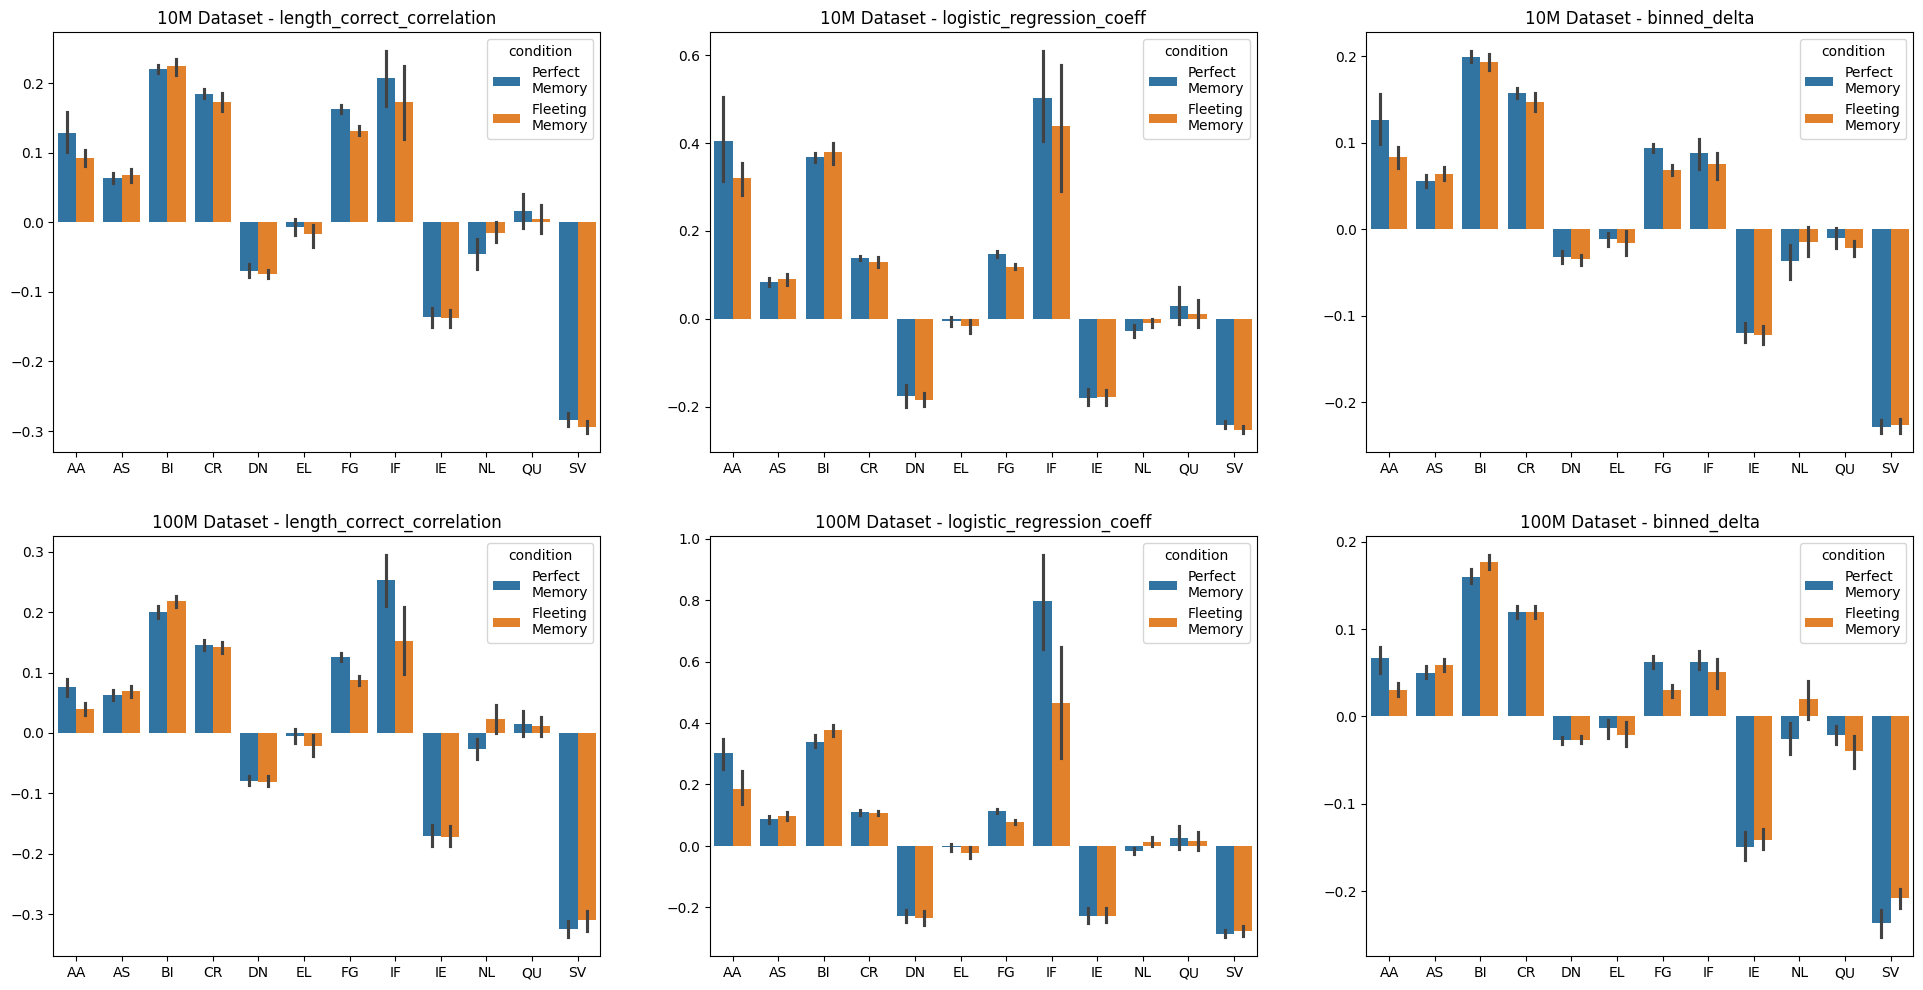

In [91]:
#Plot correlation between sentence length and correct For each subtask and each dataset and each condition

fig, ax = plt.subplots(2, 3, figsize=(24,12))

for i, dataset_size in enumerate(["10M", "100M"]):
    for j, length_sensity_coeff in enumerate(["length_correct_correlation","logistic_regression_coeff", "binned_delta"]):
        sns.barplot(data=model_correlation_results[model_correlation_results["dataset"]==dataset_size], x="Subtask", y=length_sensity_coeff, hue="condition", ax=ax[i,j])

        ax[i,j].set_title(f"{dataset_size} Dataset - {length_sensity_coeff}")
        ax[i,j].set_xlabel("")
        ax[i,j].set_ylabel("")
        ax[i,j].set_xticklabels([task_name_acronym_map[x.get_text()] for x in ax[i,j].get_xticklabels()])

In [ ]:
sns.barplot(data=model_correlation_results[model_correlation_results["dataset"]=="10M"], x="Subtask", y="length_correct_correlation", hue="condition")

plt.show()

sns.barplot(data=model_correlation_results[model_correlation_results["dataset"]=="10M"], x="Subtask", y="binned_delta", hue="condition")
plt.show()

sns.barplot(data=model_correlation_results[model_correlation_results["dataset"]=="10M"], x="Subtask", y="logistic_regression_coeff", hue="condition")
plt.show()

,ModelID,PredictedClass,SentenceGoodWordLength,SentenceBadWordLength,RowIdx,Subtask,TaskType,SentenceLength,run_id,condition,dataset
0,6681944,Good,4,4,1,anaphor_agreement,blimp,4,6681944,Fleeting\nMemory,10M
1,6681944,Good,5,5,2,anaphor_agreement,blimp,5,6681944,Fleeting\nMemory,10M
2,6681944,Good,5,5,3,anaphor_agreement,blimp,5,6681944,Fleeting\nMemory,10M
3,6681944,Good,4,4,4,anaphor_agreement,blimp,4,6681944,Fleeting\nMemory,10M
4,6681944,Good,3,3,5,anaphor_agreement,blimp,3,6681944,Fleeting\nMemory,10M
...,...,...,...,...,...,...,...,...,...,...,...
2312475,8465733,Good,3,3,39129,irregular_forms,blimp,3,8465733,Perfect\nMemory,100M
2312476,8465733,Good,5,5,39130,irregular_forms,blimp,5,8465733,Perfect\nMemory,100M
2312477,8465733,Good,5,5,39131,irregular_forms,blimp,5,8465733,Perfect\nMemory,100M
2312478,8465733,Good,5,5,39132,irregular_forms,blimp,5,8465733,Perfect\nMemory,100M


In [4]:
#Select All words from Story

story_df = pd.read_sql_query("SELECT * FROM Story", conn)

story_df

,StoryWordID,CorpusID,StoryID,WordID,Word,WordUID,POSTag,NERTag
0,1,1,1,1,If,1,ADP,
1,2,1,1,2,you,2,PRON,
2,3,1,1,3,were,3,VERB,
3,4,1,1,4,to,4,PRT,
4,5,1,1,5,journey,5,VERB,
...,...,...,...,...,...,...,...,...
61752,61753,2,20,2449,countries,5644,NOUN,
61753,61754,2,20,2450,are,286,VERB,
61754,61755,2,20,2451,pushing,9798,VERB,
61755,61756,2,20,2452,ahead,3629,ADV,


In [11]:
#Distribuation of POSTags per corpus as percentage of total words

story_df.groupby(["POSTag", "CorpusID"]).size().unstack()

CorpusID,1,2
POSTag,,
ADJ,963,4604
ADP,1258,6762
ADV,664,3221
CONJ,417,1695
DET,1320,6221
NOUN,2361,13836
NUM,54,645
PRON,773,3216
PRT,320,1708
